
# Lab 11: Understanding the data. 

Last 2 classes we have been working on understanding data. In this lab you will apply that.


**Context**
The goal of this lab is to understand a large dataset of 27901 rows and 18 columns Perform Exploratory Data Analysis (EDA) on the data. Look at how the data effects the end result **depression** (yes/no)

- Load and get a basic understanding of the dataset
- Clean up the data 
    - examples:
        - check and fix any missing data 
        - use both Hot and integer encoding
        - convert any numeric data from strings to ints
- Perform Exploratory Data Analysis (EDA) 
    - I will leave it to you to understand and explore this. 
        - Histplot
        - Countplot
        - Corelation
        - Heatmaps
        - boxplots
        - have fun

Make sure to communicate to me along the way. I want your to tell me what your assumptions are what your learning about the data and what you learned with EDA.  There are 18 data points for each student I expect an perform EDA on most of those points like what we did in class with MPG. (remember how we did a sns.pairplot(df[[ "cylinders", "mpg","model_year"]]) and sns.pairplot(df[["mpg", "horsepower", "weight", "displacement"]]) and others. ) 

remember to have fun with this 

----------------------------------------------------------------------------------------------------------------------------------------------

From: https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset/data


Field Descriptions

**id** - A unique identifier assigned to each student record in the dataset.

**Gender** - The gender of the student (e.g., Male, Female, Other). This helps in analyzing gender-specific trends in mental health.

**Age** - The age of the student in years.

**City** - The city or region where the student resides, providing geographical context for the analysis.

**Profession** - The field of work or study of the student, which may offer insights into occupational or academic stress factors.

**Academic Pressure** - A measure indicating the level of pressure the student faces in academic settings. This could include stress from exams, assignments, and overall academic expectations.

**Work Pressure** - A measure of the pressure related to work or job responsibilities, relevant for students who are employed alongside their studies.

**CGPA** - The cumulative grade point average of the student, reflecting overall academic performance.

**Study Satisfaction** - An indicator of how satisfied the student is with their studies, which can correlate with mental well-being.

**Job Satisfaction** - A measure of the student’s satisfaction with their job or work environment, if applicable.

**Sleep Duration** - The average number of hours the student sleeps per day, which is an important factor in mental health.

**Dietary Habits** - An assessment of the student’s eating patterns and nutritional habits, potentially impacting overall health and mood.

**Degree** - The academic degree or program that the student is pursuing.

**Have you ever had suicidal thoughts ?** - A binary indicator (Yes/No) that reflects whether the student has ever experienced suicidal ideation.

**Work/Study Hours** - The average number of hours per day the student dedicates to work or study, which can influence stress levels.

**Financial Stress** - A measure of the stress experienced due to financial concerns, which may affect mental health.

**Family History of Mental Illness** - Indicates whether there is a family history of mental illness (Yes/No), which can be a significant factor in mental health predispositions.

**Depression** - The target variable that indicates whether the student is experiencing depression (Yes/No).

------------------------------------------------------------------------------------------------------------------------------------------------

*Provided for reference only*
``` python 
import kagglehub
import shutil

# Download latest version
path = kagglehub.dataset_download("adilshamim8/student-depression-dataset")

#move the dowload to the current directory
shutil.move(path, "./Lab_11_dataset")
````

In [102]:
# importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# loading the dataset
df = pd.read_csv("student_depression_dataset.csv")
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


# Joanna Escobar

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

ds = pd.read_csv ("student_depression_dataset.csv")
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [104]:
print(f"Dataset Shape:\t{ds.shape}\n") # prints in (rows, columns)

# Looking for the unique answers in each section. See if there are problems with responses.
print(f"GENDER:\t{ds["Gender"].unique()}")
print(f"CITY:\t{ds["City"].unique()}") ### has some values not related to cities
print(f"PROFESSION:\t{ds["Profession"].unique()}")
print(f"SLEEP DURATION:\t{ds["Sleep Duration"].unique()}")
print(f"DIETARY HABITS:\t{ds["Dietary Habits"].unique()}")
print(f"DEGREE:\t{ds["Degree"].unique()}")
print(f"THOUGHTS:\t{ds["Have you ever had suicidal thoughts ?"].unique()}")
print(f"FINANCIAL STRESS:\t{ds["Financial Stress"].unique()}") ### Has '?' as one of its answers
print(f"MENTAL ILLNESS:\t{ds["Family History of Mental Illness"].unique()}")
print(f"DEPRESSION:\t{ds["Depression"].unique()}")

Dataset Shape:	(27901, 18)

GENDER:	['Male' 'Female']
CITY:	['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' "'Less Delhi'" 'City'
 '3.0' "'Less than 5 Kalyan'" 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh'
 'Reyansh' 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini'
 'Nandini' 'Khaziabad']
PROFESSION:	['Student' "'Civil Engineer'" 'Architect' "'UX/UI Designer'"
 "'Digital Marketer'" "'Content Writer'" "'Educational Consultant'"
 'Teacher' 'Manager' 'Chef' 'Doctor' 'Lawyer' 'Entrepreneur' 'Pharmacist']
SLEEP DURATION:	["'5-6 hours'" "'Less than 5 hours'" "'7-8 hours'" "'More than 8 hours'"
 'Others']
DIETARY HABITS:	['Healthy' 'Moderate' 'Unhealthy' 'Others']
DEGREE:	['B.Pharm' 'BSc' 'BA' 'BCA' 'M.Tech' 'P

From the above, I determined the following: 
- "City" and "Financial Stress" had issues with their responses
- "Gender", "Dietary Habits", "Thoughts", "Mental Illness" would be good for Integer Encoding at first glance.

In [105]:
# steps to cleaning dataset
ds_cleaned0 = ds.dropna()
ds_cleaned1 = ds_cleaned0[ds_cleaned0["Financial Stress"] != "?"]
ds_cleaned2 = ds_cleaned1[ds_cleaned1["City"] != "City"]
ds_cleaned3 = ds_cleaned2[ds_cleaned2["City"] != "3.0"]
ds_cleaned4 = ds_cleaned3[ds_cleaned3["City"] != "'Less than 5 Kalyan'"]
ds_cleaned5 = ds_cleaned4[ds_cleaned4["City"] != "M.Com"]
ds_cleaned6 = ds_cleaned5[ds_cleaned5["City"] != "ME"]
ds_cleaned7 = ds_cleaned6[ds_cleaned6["City"] != "M.Tech"]
ds_cleaned = ds_cleaned7[ds_cleaned7["City"] != "'Less Delhi'"]

ds_cleaned.to_csv("cleaned_student_depression_dataset.csv",index=False) # taken from GeeksforGeeks

df = pd.read_csv("cleaned_student_depression_dataset.csv")

print(f"FINANCIAL STRESS:\t{df["Financial Stress"].unique()}")
print(f"CITY:\t{df["City"].unique()}")

wo_depression = df.drop(columns="Depression")

FINANCIAL STRESS:	[1. 2. 5. 3. 4.]
CITY:	['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'Bhavna' 'Mira' 'Harsha' 'Vaanya' 'Gaurav'
 'Harsh' 'Reyansh' 'Kibara' 'Rashi' 'Nalyan' 'Mihir' 'Nalini' 'Nandini'
 'Khaziabad']


In [107]:
# Integer Encoding "Gender" and mapping #
df["Gender"] = df["Gender"].astype("category")
wo_depression["Gender"] = df["Gender"].cat.codes
wo_depression["Gender"].unique()

gender_mapping = dict(enumerate(df["Gender"].cat.categories))
print(f"Gender Mapping: {gender_mapping}")
#######################################################################
# Integer Encoding "City" #
df["City"] = df["City"].astype("category")
wo_depression["City"] = df["City"].cat.codes
wo_depression["City"].unique()

city_mapping = dict(enumerate(df["City"].cat.categories))
print(f"City Mapping: {city_mapping}")
#######################################################################
# Integer Encoding "Dietary Habits" #
df["Dietary Habits"] = df["Dietary Habits"].astype("category")
wo_depression["Dietary Habits"] = df["Dietary Habits"].cat.codes
wo_depression["Dietary Habits"].unique()

dietary_mapping = dict(enumerate(df["Dietary Habits"].cat.categories))
print(f"Dietary Mapping: {dietary_mapping}")
#######################################################################
# Integer Encoding "Thoughts" #
thoughts = "Have you ever had suicidal thoughts ?"
df[thoughts] = df[thoughts].astype("category")
wo_depression[thoughts] = df[thoughts].cat.codes
wo_depression[thoughts].unique()

thoughts_mapping = dict(enumerate(df[thoughts].cat.categories))
print(f"Thoughts Mapping: {thoughts_mapping}")
#######################################################################
# Integer Encoding "Mental Illness" #
mi = "Family History of Mental Illness"
df[mi] = df[mi].astype("category")
wo_depression[mi] = df[mi].cat.codes
wo_depression[mi].unique()

mental_mapping = dict(enumerate(df[mi].cat.categories))
print(f"Mental Mapping: {mental_mapping}")
#######################################################################
# Integer Encoding "Profession" #
df["Profession"] = df["Profession"].astype("category")
wo_depression["Profession"] = df["Profession"].cat.codes
wo_depression["Profession"].unique()

profession_mapping = dict(enumerate(df["Profession"].cat.categories))
print(f"Prof. Map.: {profession_mapping}")
#######################################################################
# Integer Encoding Dietary Habits #
df["Dietary Habits"] = df["Dietary Habits"].astype("category")
wo_depression["Dietary Habits"] = df["Dietary Habits"].cat.codes
wo_depression["Dietary Habits"].unique()

diet_mapping = dict(enumerate(df["Dietary Habits"].cat.categories))
print(f"Diet Mapping: {diet_mapping}")
#######################################################################
# Integer Encoding Degree #
df["Degree"] = df["Degree"].astype("category")
wo_depression["Degree"] = df["Degree"].cat.codes
wo_depression["Degree"].unique()

degree_mapping = dict(enumerate(df["Degree"].cat.categories))
print(f"Degree Mapping: {degree_mapping}")

#######################################################################
# # Integer Encoding "Sleep Duration" #
df["Sleep Duration"] = df["Sleep Duration"].astype("category")
wo_depression["Sleep Duration"] = df["Sleep Duration"].cat.codes
print(wo_depression["Sleep Duration"].unique())

sleep_mapping = dict(enumerate(df["Sleep Duration"].cat.categories))
print(f"Sleep Mapping: {sleep_mapping}")

Gender Mapping: {0: 'Female', 1: 'Male'}
City Mapping: {0: 'Agra', 1: 'Ahmedabad', 2: 'Bangalore', 3: 'Bhavna', 4: 'Bhopal', 5: 'Chennai', 6: 'Delhi', 7: 'Faridabad', 8: 'Gaurav', 9: 'Ghaziabad', 10: 'Harsh', 11: 'Harsha', 12: 'Hyderabad', 13: 'Indore', 14: 'Jaipur', 15: 'Kalyan', 16: 'Kanpur', 17: 'Khaziabad', 18: 'Kibara', 19: 'Kolkata', 20: 'Lucknow', 21: 'Ludhiana', 22: 'Meerut', 23: 'Mihir', 24: 'Mira', 25: 'Mumbai', 26: 'Nagpur', 27: 'Nalini', 28: 'Nalyan', 29: 'Nandini', 30: 'Nashik', 31: 'Patna', 32: 'Pune', 33: 'Rajkot', 34: 'Rashi', 35: 'Reyansh', 36: 'Saanvi', 37: 'Srinagar', 38: 'Surat', 39: 'Thane', 40: 'Vaanya', 41: 'Vadodara', 42: 'Varanasi', 43: 'Vasai-Virar', 44: 'Visakhapatnam'}
Dietary Mapping: {0: 'Healthy', 1: 'Moderate', 2: 'Others', 3: 'Unhealthy'}
Thoughts Mapping: {0: 'No', 1: 'Yes'}
Mental Mapping: {0: 'No', 1: 'Yes'}
Prof. Map.: {0: "'Civil Engineer'", 1: "'Content Writer'", 2: "'Digital Marketer'", 3: "'Educational Consultant'", 4: "'UX/UI Designer'", 5: 'Ar

In [ ]:
# Hot Encoding values
# profession = pd.get_dummies(df['Profession'])
# sleep_duration = pd.get_dummies(df['Sleep Duration'])
# dietary_habits = pd.get_dummies(df['Dietary Habits'])
# degree = pd.get_dummies(df['Degree'])
# gender = pd.get_dummies(df['Gender'])

# degree # checking degree

In [ ]:
# wo_depression = wo_depression.drop(columns = ['Degree'])
# wo_depression = pd.concat([wo_depression, degree])

# wo_depression = wo_depression.drop(columns = 'Sleep Duration')
# wo_depression = pd.concat([wo_depression, sleep_duration])

# wo_depression = wo_depression.drop(columns = ['Gender'])
# wo_depression = pd.concat([wo_depression, gender])

In trying to use hot encoding, I kept coming across errors where the hot encoded values would not be correlated with any other values. This was negatively affecting the data analysis, so I decided to integer encode all of the values.

In [108]:
wo_depression.corr()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
id,1.000000,-0.004742,0.003901,-0.007011,0.006923,0.005117,0.001260,-0.012432,0.007944,0.001930,-0.006604,-0.010386,-0.000915,0.004559,-0.004341,0.000662,-0.005695
Gender,-0.004742,1.000000,0.009027,-0.025154,0.007267,-0.022271,0.008715,0.035992,-0.016023,0.007171,0.011979,0.063159,0.009232,-0.001286,0.013023,-0.005478,-0.015887
Age,0.003901,0.009027,1.000000,0.047154,-0.006248,-0.075790,0.002016,0.005110,0.009317,-0.000430,-0.010117,-0.061530,0.423476,-0.113321,-0.032925,-0.094864,-0.004765
City,-0.007011,-0.025154,0.047154,1.000000,0.016994,-0.021496,-0.001999,-0.028727,0.006841,-0.004885,-0.011409,-0.011467,0.023410,-0.005605,-0.002551,-0.003691,0.004331
Profession,0.006923,0.007267,-0.006248,0.016994,1.000000,-0.013156,0.000258,-0.006241,-0.006531,0.000405,-0.000166,0.013701,-0.016631,-0.007420,0.006289,-0.010317,-0.008259
Academic Pressure,0.005117,-0.022271,-0.075790,-0.021496,-0.013156,1.000000,-0.022236,-0.022334,-0.111177,-0.024951,-0.006563,0.091089,-0.053786,0.261383,0.096036,0.151548,0.030067
Work Pressure,0.001260,0.008715,0.002016,-0.001999,0.000258,-0.022236,1.000000,-0.050902,-0.021152,0.770652,-0.008538,-0.006962,-0.010516,-0.001007,-0.005468,0.001882,-0.006210
CGPA,-0.012432,0.035992,0.005110,-0.028727,-0.006241,-0.022334,-0.050902,1.000000,-0.044140,-0.053638,-0.021217,0.001196,-0.007338,0.008424,0.002671,0.005707,-0.003863
Study Satisfaction,0.007944,-0.016023,0.009317,0.006841,-0.006531,-0.111177,-0.021152,-0.044140,1.000000,-0.021915,0.003732,-0.017165,-0.026528,-0.083689,-0.036604,-0.065173,-0.003868
Job Satisfaction,0.001930,0.007171,-0.000430,-0.004885,0.000405,-0.024951,0.770652,-0.053638,-0.021915,1.000000,-0.003586,-0.003160,-0.006599,-0.003394,-0.005222,0.005247,-0.010013


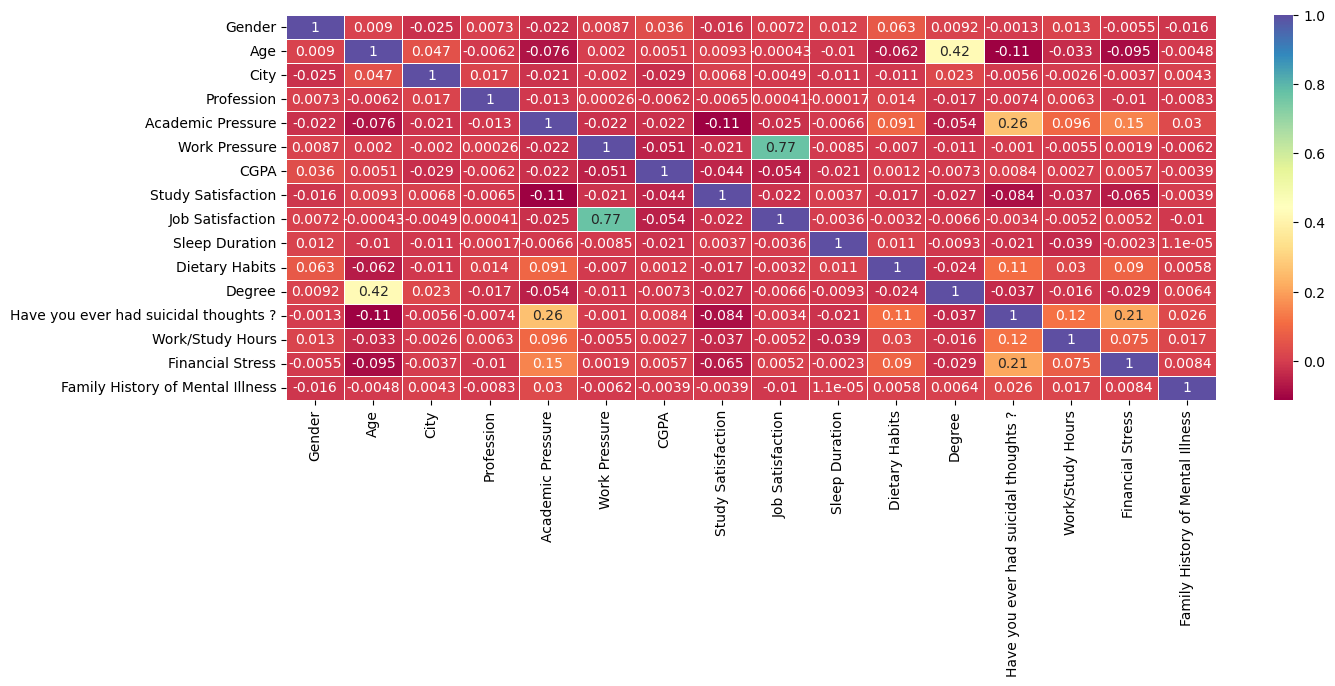

In [109]:
plt.figure(figsize = (15,5))
wo_depression = wo_depression.drop(columns=['id'])
sns.heatmap(wo_depression.corr(), annot = True, linewidth = 0.5, cmap = "Spectral")
plt.show()

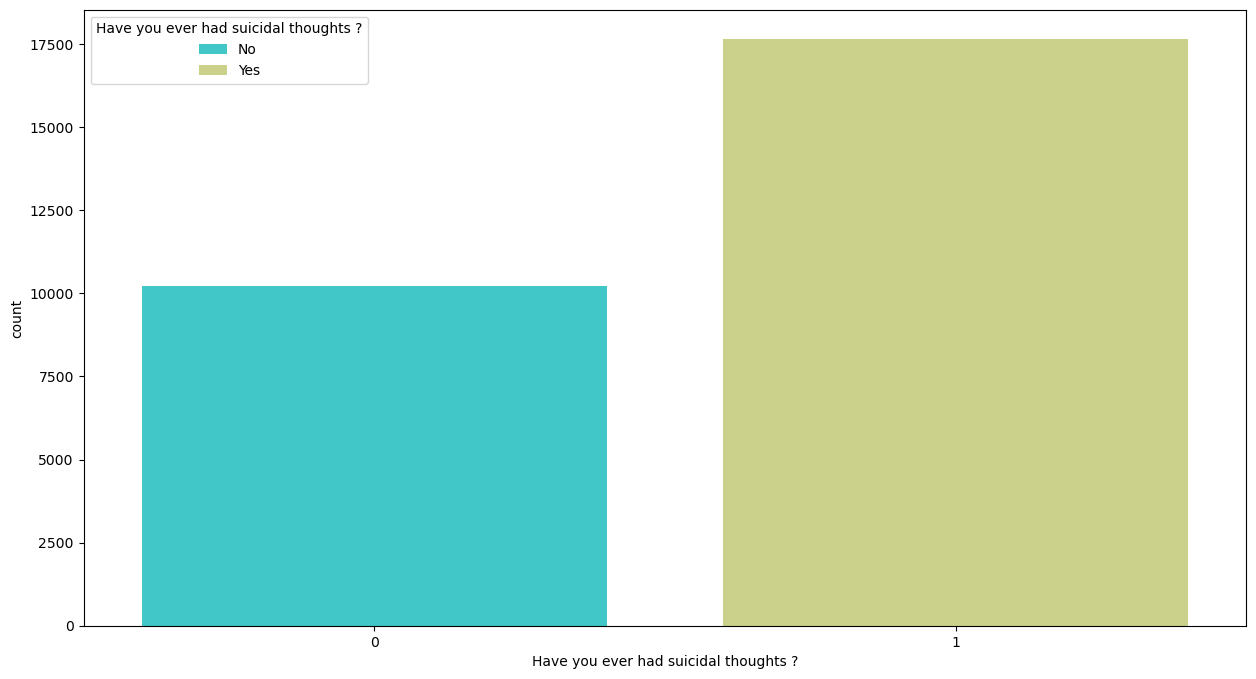

In [110]:
plt.figure(figsize = (15, 8))
sns.countplot(x=wo_depression[thoughts], data = df, palette = "rainbow", hue = thoughts)
plt.show()